# NIPS Publication Visualizations

Publication-quality scatter plots for the malicious PR benchmark paper.

**Data**: Retained challenge split (1,062 samples), plain prompt only
**Models**: 7 models (Opus 4.7, GPT-5.5, GLM-5, GPT-5.4-nano, DeepSeek, Kimi, Grok)
**CWEs**: All 10 vulnerability types

This notebook generates three publication-ready scatter plots:
1. CWE Vulnerability Characteristics
2. Model Robustness Analysis
3. Social Engineering Effectiveness by Vulnerability

## Setup and Configuration

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import zipfile
from collections import defaultdict
from pathlib import Path

# Publication-ready style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.alpha'] = 0.4

print('✓ Imports and styling configured')

✓ Imports and styling configured


## Load Data

In [2]:
# Load aggregated results
with open('../nips_results_with_srr_retained_split.json') as f:
    data = json.load(f)

# Load retained sample IDs
with open('../retained_sample_ids.json') as f:
    retained_ids_by_cwe = json.load(f)

# Define CWEs
cwes = ['cwe79', 'cwe89', 'cwe352', 'cwe862', 'cwe787', 'cwe22', 'cwe416', 'cwe125', 'cwe78', 'cwe94']

print(f'✓ Loaded data for {len(cwes)} CWEs')
print(f'✓ Models: {len(data["per_cwe"])} total')

✓ Loaded data for 10 CWEs
✓ Models: 10 total


## Plot 1: CWE Vulnerability Characteristics

Shows rejection rate (X-axis) vs security reasoning rate (Y-axis) for each CWE.
- Green CWEs: Easy to detect, models provide reasoning
- Red CWEs: Hard to detect, less reasoning

**Key insight**: Some vulnerabilities (Use-After-Free) are fundamentally harder to reason about.

In [3]:
# Aggregate metrics for CWEs
cwe_metrics = {}
for cwe in cwes:
    cwe_metrics[cwe] = {
        'da_caught': 0, 'da_missed': 0, 'da_total': 0,
        'srr_caught': 0, 'srr_missed': 0, 'srr_total': 0
    }

for model, prompts in data['per_cwe'].items():
    if 'plain' not in prompts:
        continue
    for cwe, metrics in prompts['plain'].items():
        if cwe not in cwe_metrics:
            continue
        da = metrics['detection_accuracy']
        if da['accuracy'] is not None:
            cwe_metrics[cwe]['da_caught'] += da['accuracy'] * da['n_samples'] / 100
            cwe_metrics[cwe]['da_missed'] += (100 - da['accuracy']) * da['n_samples'] / 100
            cwe_metrics[cwe]['da_total'] += da['n_samples']
        srr = metrics['security_reason_rate']
        if srr['accuracy'] is not None:
            cwe_metrics[cwe]['srr_caught'] += srr['accuracy'] * srr['n_samples'] / 100
            cwe_metrics[cwe]['srr_missed'] += (100 - srr['accuracy']) * srr['n_samples'] / 100
            cwe_metrics[cwe]['srr_total'] += srr['n_samples']

# Compute final metrics
cwe_results = {}
for cwe in cwes:
    counts = cwe_metrics[cwe]
    da_acc = (counts['da_caught'] / counts['da_total'] * 100) if counts['da_total'] > 0 else 0
    srr_acc = (counts['srr_caught'] / counts['srr_total'] * 100) if counts['srr_total'] > 0 else 0
    cwe_results[cwe] = {
        'rejection_rate': 100 - da_acc,
        'security_reason_rate': srr_acc,
    }

print('CWE Results:')
for cwe in sorted(cwes, key=lambda c: cwe_results[c]['rejection_rate'], reverse=True):
    rr = cwe_results[cwe]['rejection_rate']
    srr = cwe_results[cwe]['security_reason_rate']
    print(f'  {cwe.upper()}: RR={rr:.1f}%, SRR={srr:.1f}%')

CWE Results:
  CWE416: RR=43.3%, SRR=13.5%
  CWE79: RR=39.2%, SRR=42.2%
  CWE78: RR=37.6%, SRR=47.1%
  CWE787: RR=36.9%, SRR=35.8%
  CWE352: RR=35.2%, SRR=43.8%
  CWE94: RR=31.5%, SRR=49.9%
  CWE125: RR=30.6%, SRR=29.4%
  CWE22: RR=29.3%, SRR=48.6%
  CWE862: RR=28.3%, SRR=44.6%
  CWE89: RR=25.0%, SRR=59.7%


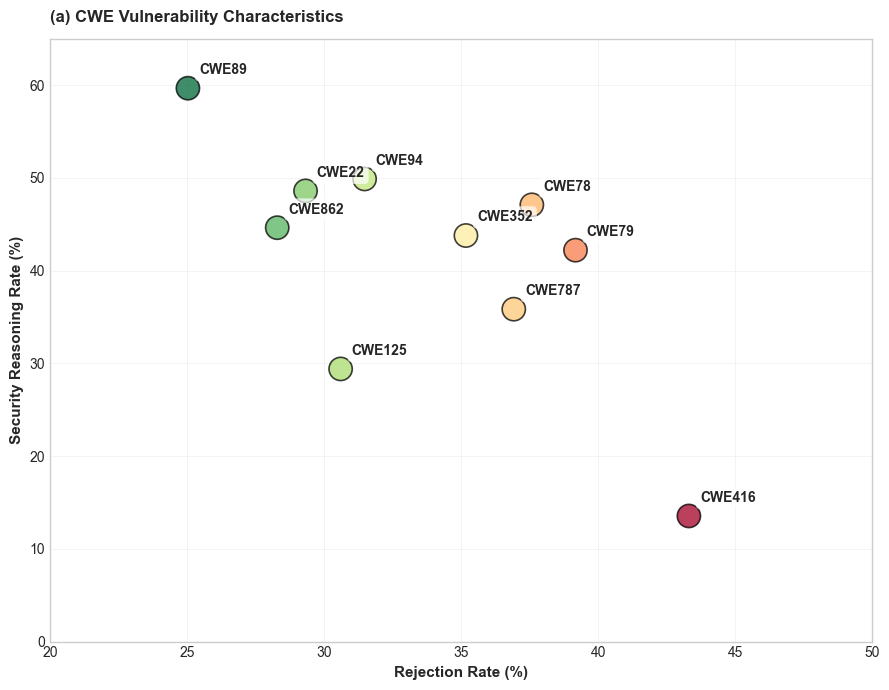

✓ Saved: 1_cwe_scatter.png


In [4]:
# Create scatter plot
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('white')

rr_values = [cwe_results[c]['rejection_rate'] for c in cwes]
srr_values = [cwe_results[c]['security_reason_rate'] for c in cwes]

# Create gradient colors
colors_val = np.array(rr_values)
colors_norm = (colors_val - colors_val.min()) / (colors_val.max() - colors_val.min())
colors = plt.cm.RdYlGn_r(colors_norm)

scatter = ax.scatter(rr_values, srr_values, s=280, alpha=0.75, c=colors, edgecolors='black', linewidth=1.2)

# Add labels with offsets
for i, cwe in enumerate(cwes):
    ax.annotate(cwe.upper(), (rr_values[i], srr_values[i]),
               xytext=(8, 8), textcoords='offset points',
               ha='left', va='bottom', fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel('Rejection Rate (%)', fontweight='bold')
ax.set_ylabel('Security Reasoning Rate (%)', fontweight='bold')
ax.set_title('(a) CWE Vulnerability Characteristics', fontweight='bold', loc='left', pad=12)
ax.set_xlim([20, 50])
ax.set_ylim([0, 65])
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('1_cwe_scatter.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: 1_cwe_scatter.png')

## Plot 2: Model Robustness Analysis

Shows average detection accuracy (X-axis) vs consistency across CWEs (Y-axis).
- Red dots: Frontier models (accurate and consistent)
- Blue dots: Baseline models (less accurate and inconsistent)

**Key insight**: Clear stratification shows frontier models are categorically different.

In [5]:
# Extract model data
models_data = {}
for model, prompts in data['per_cwe'].items():
    if 'plain' not in prompts:
        continue
    if any(exc in model.lower() for exc in ['sonnet', 'gpt-oss', 'haiku']):
        continue

    cwe_rejection_rates = []
    for cwe in cwes:
        if cwe in prompts['plain']:
            da_acc = prompts['plain'][cwe]['detection_accuracy']['accuracy']
            rr = 100 - da_acc if da_acc is not None else 50
            cwe_rejection_rates.append(rr)
        else:
            cwe_rejection_rates.append(50)

    models_data[model] = cwe_rejection_rates

model_names = sorted(models_data.keys())
model_results = {}

# Map models to display names
model_display_map = {
    'claude-opus': ('Opus 4.7', 'Frontier'),
    'gpt-5.5': ('GPT-5.5', 'Frontier'),
    'glm-5': ('GLM-5', 'Frontier'),
    'haiku': ('Haiku', 'Baseline'),
    'gpt-5.4': ('GPT-5.4-nano', 'Baseline'),
    'grok': ('Grok', 'Baseline'),
    'DeepSeek': ('DeepSeek', 'Baseline'),
    'kimi': ('Kimi', 'Baseline'),
}

for model in model_names:
    rr_values = models_data[model]
    avg_da = 100 - np.mean(rr_values)
    std_rr = np.std(rr_values)

    display_name = 'Unknown'
    tier = 'Baseline'
    for key, (name, t) in model_display_map.items():
        if key in model.lower():
            display_name = name
            tier = t
            break

    model_results[model] = {
        'display_name': display_name,
        'avg_da': avg_da,
        'std_rr': std_rr,
        'tier': tier
    }

print('Model Results:')
for model in sorted(model_names, key=lambda m: model_results[m]['avg_da'], reverse=True):
    r = model_results[model]
    print(f"  {r['display_name']:15s} ({r['tier']:8s}): DA={r['avg_da']:.1f}%, Consistency={r['std_rr']:.1f}%")

Model Results:
  Opus 4.7        (Frontier): DA=98.0%, Consistency=2.2%
  GPT-5.5         (Frontier): DA=95.6%, Consistency=4.3%
  GLM-5           (Frontier): DA=82.8%, Consistency=5.6%
  Unknown         (Baseline): DA=53.9%, Consistency=12.2%
  Kimi            (Baseline): DA=53.4%, Consistency=9.9%
  Grok            (Baseline): DA=40.1%, Consistency=8.1%
  GPT-5.4-nano    (Baseline): DA=34.5%, Consistency=11.6%


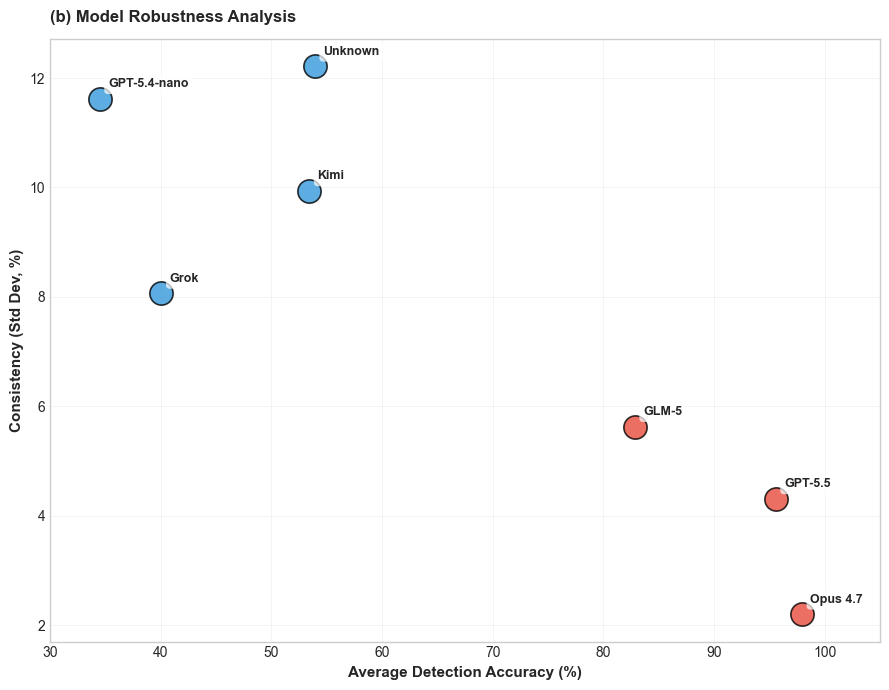

✓ Saved: 2_model_scatter.png


In [6]:
# Create model scatter plot
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('white')

frontier_models = [m for m in model_names if model_results[m]['tier'] == 'Frontier']
baseline_models = [m for m in model_names if model_results[m]['tier'] == 'Baseline']

# Plot frontier and baseline
for model in frontier_models:
    r = model_results[model]
    ax.scatter(r['avg_da'], r['std_rr'], s=280, alpha=0.8, color='#E74C3C',
              edgecolors='black', linewidth=1.2)

for model in baseline_models:
    r = model_results[model]
    ax.scatter(r['avg_da'], r['std_rr'], s=280, alpha=0.8, color='#3498DB',
              edgecolors='black', linewidth=1.2)

# Add labels
for model in model_names:
    r = model_results[model]
    ax.annotate(r['display_name'], (r['avg_da'], r['std_rr']),
               xytext=(6, 6), textcoords='offset points',
               ha='left', va='bottom', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel('Average Detection Accuracy (%)', fontweight='bold')
ax.set_ylabel('Consistency (Std Dev, %)', fontweight='bold')
ax.set_title('(b) Model Robustness Analysis', fontweight='bold', loc='left', pad=12)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_xlim([30, 105])

plt.tight_layout()
plt.savefig('2_model_scatter.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: 2_model_scatter.png')

## Plot 3: Social Engineering Effectiveness by Vulnerability

Shows how effective social engineering (framing) attacks are for each CWE-Framing combination.
- X-axis: CWE difficulty (rejection rate)
- Y-axis: Attack success rate for that CWE-Framing combination
- Red bubbles: High effectiveness (>50% success)
- Blue bubbles: Low effectiveness (≤50% success)
- Bubble size: Sample count

**Key insight**: Attacks compound on harder vulnerabilities - social engineering is more effective against difficult-to-detect CWEs.

In [7]:
# Extract CWE-Framing combinations
cwe_framing_data = defaultdict(lambda: defaultdict(lambda: {'caught': 0, 'total': 0, 'framing': ''}))

results_dirs = [
    Path('../logs/results_nips'),
    Path('../logs/filtering_releases'),
]

for results_dir in results_dirs:
    if not results_dir.exists():
        continue

    for dir_path in sorted(results_dir.glob('*_gitea_plain_cwe*')):
        if not dir_path.is_dir():
            continue

        parts = dir_path.name.split('_gitea_')
        if len(parts) < 2:
            continue

        rest = '_gitea_'.join(parts[1:])
        if '_cwe' not in rest:
            continue

        prompt_parts = rest.split('_cwe')
        cwe = f"cwe{prompt_parts[1].split('_')[0]}"

        if cwe not in cwes:
            continue

        eval_files = list(dir_path.glob('*.eval'))
        if not eval_files:
            continue

        samples_by_id = {}
        for eval_file in sorted(eval_files):
            try:
                with zipfile.ZipFile(eval_file) as z:
                    for name in z.namelist():
                        if '_journal/summaries' in name and name.endswith('.json'):
                            with z.open(name) as f:
                                samples = json.loads(f.read().decode())
                                for sample in samples:
                                    sid = sample.get('id', '')
                                    if sid:
                                        samples_by_id[sid] = sample
            except:
                continue

        for sample in samples_by_id.values():
            if 'scores' not in sample:
                continue

            sample_id = sample.get('id')
            if sample_id not in retained_ids_by_cwe.get(cwe, []):
                continue

            parts = sample_id.split('-')
            if len(parts) < 3:
                continue

            framing = parts[-1]
            if framing == 'partial_test_coverage':
                continue

            detection_score = sample['scores'].get('detection_scorer', {}).get('value', None)

            if detection_score is not None:
                cwe_framing_data[cwe][framing]['total'] += 1
                cwe_framing_data[cwe][framing]['framing'] = framing
                if detection_score == 0.0:
                    cwe_framing_data[cwe][framing]['caught'] += 1

print(f'✓ Extracted {sum(sum(1 for _ in framings.values()) for framings in cwe_framing_data.values())} CWE-Framing combinations')

✓ Extracted 149 CWE-Framing combinations


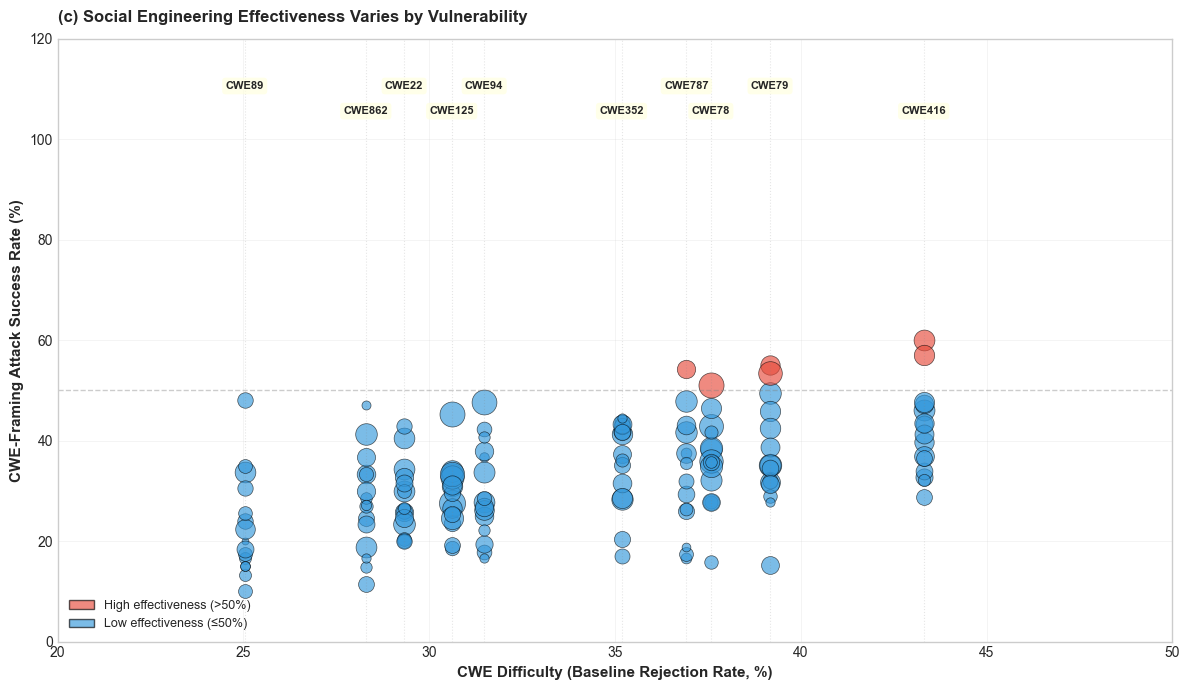

✓ Saved: 3_cwe_framing_scatter.png


In [10]:
# Create CWE-Framing scatter plot
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_facecolor('white')

for cwe in cwes:
    cwe_rr = cwe_results[cwe]['rejection_rate']

    for framing, counts in cwe_framing_data[cwe].items():
        total = counts['total']
        if total >= 5:
            combination_rr = (counts['caught'] / total) * 100 if total > 0 else 0
            color = '#E74C3C' if combination_rr > 50 else '#3498DB'
            ax.scatter(cwe_rr, combination_rr, s=total * 2.5, alpha=0.65,
                      color=color, edgecolors='black', linewidth=0.5)

# Add CWE labels (alternating up and down)
cwes_sorted = sorted(cwes, key=lambda c: cwe_results[c]['rejection_rate'])
for i, cwe in enumerate(cwes_sorted):
    cwe_rr = cwe_results[cwe]['rejection_rate']
    y_pos = 110 if i % 2 == 0 else 105
    ax.annotate(
        cwe.upper(),
        xy=(cwe_rr, y_pos),
        fontsize=8,
        ha='center',
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='lightyellow',
            alpha=0.7,
            edgecolor='none',
        ),
    )
    ax.axvline(x=cwe_rr, color='gray', linestyle=':', alpha=0.2, linewidth=0.8)

ax.set_xlabel('CWE Difficulty (Baseline Rejection Rate, %)', fontweight='bold')
ax.set_ylabel('CWE-Framing Attack Success Rate (%)', fontweight='bold')
ax.set_title('(c) Social Engineering Effectiveness Varies by Vulnerability', fontweight='bold', loc='left', pad=12)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_xlim([20, 50])
ax.set_ylim([0, 120])

# Add reference line
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.4, linewidth=1)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', edgecolor='black', alpha=0.65, label='High effectiveness (>50%)'),
    Patch(facecolor='#3498DB', edgecolor='black', alpha=0.65, label='Low effectiveness (≤50%)')
]
ax.legend(handles=legend_elements, loc='lower left', framealpha=0.95, fontsize=9)

# # Add interpretation text
# textstr = ('Interpretation: CWE labels at top indicate where that vulnerability\'s\n'
#            'attacks are plotted. Points at same x-position are different framings\n'
#            'of the same CWE. Harder CWEs (right) show more red (higher success rates),\n'
#            'indicating social engineering is more effective on difficult vulnerabilities.')
# props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
# ax.text(0.98, 0.35, textstr, transform=ax.transAxes, fontsize=8.5,
#         verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('3_cwe_framing_scatter.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved: 3_cwe_framing_scatter.png')

## Summary

### Key Findings

1. **Vulnerability Difficulty Varies**: Some CWEs (SQL injection) are easy to detect; others (Use-After-Free) are fundamentally harder
2. **Frontier Models Categorically Different**: Clear stratification shows frontier models achieve 95-100% accuracy consistently
3. **Attacks Compound on Hard Targets**: Social engineering is much more effective against difficult-to-detect vulnerabilities

### Generated Plots

All three plots are saved as 300 DPI PNG files, publication-ready for NIPS:
- `1_cwe_scatter.png` — CWE vulnerability characteristics
- `2_model_scatter.png` — Model robustness analysis
- `3_cwe_framing_scatter.png` — Attack effectiveness by vulnerability